In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, roc_curve, roc_auc_score, auc
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

In [13]:
tennis_court_df = pd.read_csv('tennis_court_data.csv', sep = ';')

In [14]:
del tennis_court_df['Day']

In [15]:
tennis_court_df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mind,High,Weak,Yes
4,Rain,Cold,Normal,Weak,Yes


In [16]:
tennis_court_df.shape

(14, 5)

In [17]:
label_encoder = LabelEncoder()

In [18]:
tennis_court_df = tennis_court_df.apply(label_encoder.fit_transform)
tennis_court_df.head(5)

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


In [19]:
X = tennis_court_df.drop(['PlayTennis'], axis = 1)
y = tennis_court_df.PlayTennis

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [21]:
# classifier = DecisionTreeClassifier(criterion = 'gini')
# classifier = DecisionTreeClassifier(criterion = 'entropy')
classifier = DecisionTreeClassifier(criterion = 'entropy', splitter = 'best')
classifier.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred = classifier.predict(X_test)

In [23]:
accuracy_score(y_test, y_pred)

0.3333333333333333

[Text(0.3333333333333333, 0.9, 'x[0] <= 1.5\nentropy = 0.845\nsamples = 11\nvalue = [3, 8]'),
 Text(0.16666666666666666, 0.7, 'entropy = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.25, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[1] <= 0.5\nentropy = 0.971\nsamples = 5\nvalue = [3, 2]'),
 Text(0.41666666666666663, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.5, 'x[3] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.3, 'x[1] <= 1.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.3, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]')]

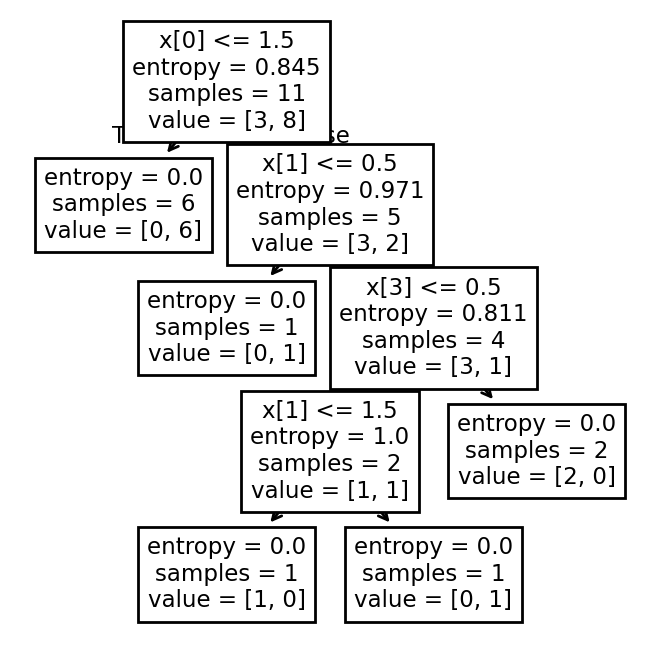

In [24]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 4), dpi = 200)
tree.plot_tree(classifier)

In [26]:
cleaned_df = pd.read_csv('cleaned_dataset.csv', sep = ';')

In [28]:
del cleaned_df['№']

In [29]:
cleaned_df.head()

,Age,Sex,CP,TrestBPS,Chol,FBS,RestECG,ThalAC,Exang,OldPeak,Spole,CA,Thal,Target
0,42,1,2,136,342,0,0,103,0,1.97,1,0.05,0.17,1
1,42,0,0,144,349,0,1,157,0,1.20,0,0.05,0.18,0
2,53,0,2,126,316,0,1,192,0,3.42,2,0.07,0.11,0
3,65,1,3,131,261,0,0,129,1,0.36,0,0.01,0.19,0
4,70,0,0,137,365,0,1,104,1,3.40,0,0.08,0.18,1


In [32]:
X = cleaned_df.drop('Target', axis = 1)
y = cleaned_df['Target']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
y_pred_logistic_regression = logistic_regression.predict(X_test)
logistic_regression_accuracy_score = accuracy_score(y_test, y_pred_logistic_regression)
logistic_regression_f1_score = f1_score(y_test, y_pred_logistic_regression)
logistic_regression_confusion_matrix = confusion_matrix(y_test, y_pred_logistic_regression)

In [41]:
print(f"Accuracy Score: {logistic_regression_accuracy_score}")
print(f"F1 Score (Test): {logistic_regression_f1_score}")
print(f"Confusion Matrix:\n {logistic_regression_confusion_matrix}")

Accuracy Score: 0.65
F1 Score (Test): 0.6111111111111112
Confusion Matrix:
 [[15  8]
 [ 6 11]]


In [42]:
print(f"Classification Report:\n {classification_report(y_test, y_pred_logistic_regression)}")

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.65      0.68        23
           1       0.58      0.65      0.61        17

    accuracy                           0.65        40
   macro avg       0.65      0.65      0.65        40
weighted avg       0.66      0.65      0.65        40



In [44]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
y_pred_decision_tree = decision_tree.predict(X_test)
decision_tree_accuracy_score = accuracy_score(y_test, y_pred_decision_tree)
decision_tree_f1_score = f1_score(y_test, y_pred_decision_tree)
decision_tree_confusion_matrix = confusion_matrix(y_test, y_pred_decision_tree)

In [45]:
print(f"Accuracy Score: {decision_tree_accuracy_score}")
print(f"F1 Score (Test): {decision_tree_f1_score}")
print(f"Confusion Matrix:\n {decision_tree_confusion_matrix}")

Accuracy Score: 0.6
F1 Score (Test): 0.5555555555555556
Confusion Matrix:
 [[14  9]
 [ 7 10]]


In [46]:
print(f"Classification Report:\n {classification_report(y_test, y_pred_decision_tree)}")

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.61      0.64        23
           1       0.53      0.59      0.56        17

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.61      0.60      0.60        40



In [47]:
model_ev = pd.DataFrame({
    "Model": ['Logistic Regresion Model', 'Desicion Tree'],
    "Accuracy Score": [logistic_regression_accuracy_score, decision_tree_accuracy_score],
    "F1 Score": [logistic_regression_f1_score, decision_tree_f1_score],
})
model_ev

,Model,Accuracy Score,F1 Score
0,Logistic Regresion Model,0.65,0.611111
1,Desicion Tree,0.60,0.555556


In [50]:
y_prob_logistic = logistic_regression.predict_proba(X_test)[:, 1]
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

In [51]:
fpr_logistic_regression, tpr_logistic_regression, thresholds_logistic_regression = roc_curve(y_test, y_prob_logistic)
fpr_decision_tree, tpr_decision_tree, thresholds_decision_tree = roc_curve(y_test, y_prob_tree)

In [53]:
roc_auc_logistic_regression = auc(fpr_logistic_regression, tpr_logistic_regression)
roc_auc_decision_tree = auc(fpr_decision_tree, tpr_decision_tree)

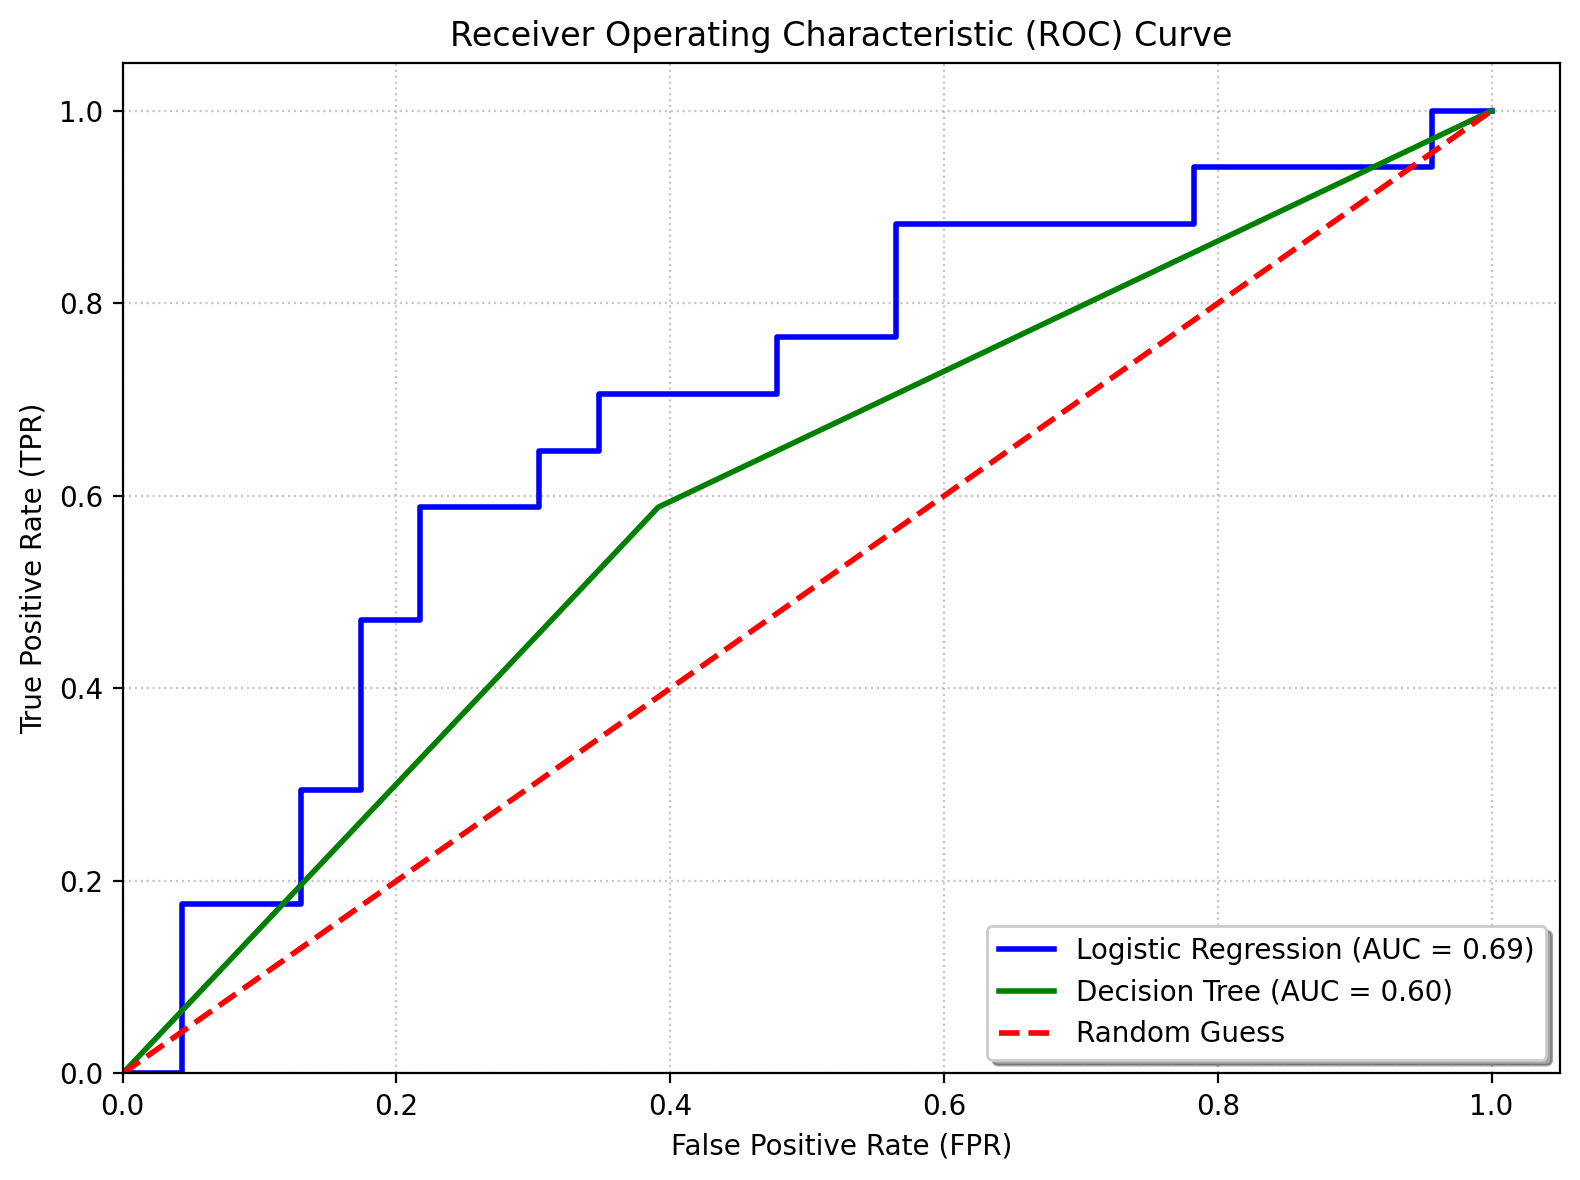

In [58]:
roc_auc_logistic_regression = auc(fpr_logistic_regression, tpr_logistic_regression)
roc_auc_decisio_tree = auc(fpr_decision_tree, tpr_decision_tree)
plt.figure(figsize = (8, 6), dpi = 200)
plt.plot(
    fpr_logistic_regression,
    tpr_logistic_regression, 
    color = 'blue', 
    lw = 2, 
    label = f'Logistic Regression (AUC = {roc_auc_logistic:.2f})'
)
plt.plot(
    fpr_decision_tree, 
    tpr_decision_tree, 
    color = 'green', 
    lw = 2, 
    label = f'Decision Tree (AUC = {roc_auc_tree:.2f})'
)
plt.plot(
    [0, 1], 
    [0, 1], 
    color = 'red',
    lw = 2, 
    linestyle = '--', 
    label = 'Random Guess'
)
plt.xlim([0.0, 1.05]) 
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc = 'lower right', fontsize = 10, frameon = True, shadow = True)
plt.grid(True, linestyle = ':', alpha = 0.7)
plt.tight_layout()
plt.show()